In [6]:
import ccxt

exchange = ccxt.okx({
    "enableRateLimit": True,
})

markets = exchange.load_markets()
market = markets["BTC/USDT"]

print("maker:", market.get("maker"))
print("taker:", market.get("taker"))

maker: 0.001
taker: 0.0015


In [7]:
order_book = exchange.fetch_order_book(
    "BTC/USDT",
    limit=20,
)

best_bid = order_book["bids"][0][0]
best_ask = order_book["asks"][0][0]
mid_price = (best_bid + best_ask) / 2

spread_rate = (best_ask - best_bid) / mid_price

print(f"买一价：{best_bid}")
print(f"卖一价：{best_ask}")
print(f"价差比例：{spread_rate:.4%}")

买一价：62557.1
卖一价：62557.2
价差比例：0.0002%


In [9]:
def estimate_market_buy_price(asks, quote_amount):
    remaining_quote = quote_amount
    base_bought = 0
    quote_spent = 0

    for level in asks:
        price, amount = level[:2]

        level_quote = price * amount
        spend = min(remaining_quote, level_quote)

        base_bought += spend / price
        quote_spent += spend
        remaining_quote -= spend

        if remaining_quote <= 0:
            break

    if remaining_quote > 0:
        return None

    return quote_spent / base_bought


quote_amount = 1000
average_buy_price = estimate_market_buy_price(
    order_book["asks"],
    quote_amount,
)

buy_slippage = (
    average_buy_price - mid_price
) / mid_price

print(f"估算买入均价：{average_buy_price}")
print(f"估算买入滑点：{buy_slippage:.4%}")

估算买入均价：62557.2
估算买入滑点：0.0001%


In [10]:
fee_rate = 0.001
slippage_rate = 0.0005

single_trade_cost_rate = fee_rate + slippage_rate

In [12]:
import pandas as pd

file_path = "../chapter04/data/btc_usdt_1d.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["timestamp"],
    index_col="timestamp",
)

df = df.sort_index()

print(df.head())
print(df.tail())

                               open      high       low     close       volume
timestamp                                                                     
2025-08-28 00:00:00+00:00  111254.1  113484.9  110869.6  112564.0  5118.996882
2025-08-29 00:00:00+00:00  112564.1  112642.0  107474.9  108385.7  7323.836956
2025-08-30 00:00:00+00:00  108385.8  108922.9  107343.7  108815.0  4987.664210
2025-08-31 00:00:00+00:00  108815.1  109486.0  108064.9  108248.3  2305.232282
2025-09-01 00:00:00+00:00  108248.0  109911.0  107250.0  109235.9  4341.712476
                              open     high      low    close       volume
timestamp                                                                 
2026-06-19 00:00:00+00:00  62953.3  63664.0  62310.1  63541.0  5700.907189
2026-06-20 00:00:00+00:00  63541.0  64384.5  63200.0  64300.0  7039.788795
2026-06-21 00:00:00+00:00  64300.1  64594.0  63262.0  63313.0  6447.301976
2026-06-22 00:00:00+00:00  63313.1  65629.5  63313.1  64027.6  6066.3150

In [13]:
df["ma20"] = df["close"].rolling(window=20).mean()
df["ma60"] = df["close"].rolling(window=60).mean()
df["trend_up"] = df["ma20"] > df["ma60"]

In [14]:
previous_ma20 = df["ma20"].shift(1)
previous_ma60 = df["ma60"].shift(1)

df["buy_signal"] = (
    (previous_ma20 <= previous_ma60)
    & (df["ma20"] > df["ma60"])
)

df["sell_signal"] = (
    (previous_ma20 >= previous_ma60)
    & (df["ma20"] < df["ma60"])
)

In [15]:
df["target_position"] = pd.Series(
    index=df.index,
    dtype="float",
)

df.loc[df["buy_signal"], "target_position"] = 1
df.loc[df["sell_signal"], "target_position"] = 0

df["position"] = (
    df["target_position"]
    .ffill()
    .fillna(0)
    .shift(1, fill_value=0)
    .astype(int)
)

print(df[["buy_signal", "sell_signal", "position"]].tail())

                           buy_signal  sell_signal  position
timestamp                                                   
2026-06-19 00:00:00+00:00       False        False         0
2026-06-20 00:00:00+00:00       False        False         0
2026-06-21 00:00:00+00:00       False        False         0
2026-06-22 00:00:00+00:00       False        False         0
2026-06-23 00:00:00+00:00       False        False         0


In [16]:
df["open_to_next_open_return"] = (
    df["open"].shift(-1) / df["open"] - 1
)

In [17]:
df["strategy_return"] = (
    df["position"] * df["open_to_next_open_return"]
)

In [18]:
df["benchmark_return"] = df["open_to_next_open_return"]

In [19]:
backtest = df.dropna(
    subset=["open_to_next_open_return"]
).copy()

In [20]:
backtest = backtest.loc[
    backtest["ma60"].notna()
].copy()


In [21]:
backtest["trade"] = (
    backtest["position"]
    .diff()
    .abs()
    .fillna(backtest["position"])
)

print(backtest["trade"].value_counts())

trade
0.0    234
1.0      6
Name: count, dtype: int64


In [22]:
backtest["strategy_return"] = (
    backtest["position"] * backtest["open_to_next_open_return"]
)

In [23]:
backtest["cost_rate"] = (
    backtest["trade"] * single_trade_cost_rate
)

In [24]:
backtest["strategy_return_with_cost"] = (
    backtest["position"] * backtest["open_to_next_open_return"]
    - backtest["cost_rate"]
)

In [25]:
initial_cash = 1000

In [26]:
backtest["strategy_equity_no_cost"] = (
    initial_cash
    * (1 + backtest["strategy_return"]).cumprod()
)

In [27]:
backtest["strategy_equity_with_cost"] = (
    initial_cash
    * (1 + backtest["strategy_return_with_cost"]).cumprod()
)

In [28]:
backtest["benchmark_equity"] = (
    initial_cash
    * (1 + backtest["benchmark_return"]).cumprod()
)

In [29]:
strategy_return_no_cost = (
    backtest["strategy_equity_no_cost"].iloc[-1]
    / initial_cash
    - 1
)

strategy_return_with_cost = (
    backtest["strategy_equity_with_cost"].iloc[-1]
    / initial_cash
    - 1
)

benchmark_return = (
    backtest["benchmark_equity"].iloc[-1]
    / initial_cash
    - 1
)

print(f"策略收益率（无成本）：{strategy_return_no_cost:.2%}")
print(f"策略收益率（含成本）：{strategy_return_with_cost:.2%}")
print(f"买入持有收益率：{benchmark_return:.2%}")

策略收益率（无成本）：-19.56%
策略收益率（含成本）：-20.27%
买入持有收益率：-42.65%


In [30]:
def calculate_drawdown(equity_curve):
    historical_peak = equity_curve.cummax()
    drawdown = equity_curve / historical_peak - 1
    return drawdown

In [31]:
backtest["drawdown_no_cost"] = calculate_drawdown(
    backtest["strategy_equity_no_cost"]
)

backtest["drawdown_with_cost"] = calculate_drawdown(
    backtest["strategy_equity_with_cost"]
)

backtest["benchmark_drawdown"] = calculate_drawdown(
    backtest["benchmark_equity"]
)

print(f"策略最大回撤（无成本）：{backtest['drawdown_no_cost'].min():.2%}")
print(f"策略最大回撤（含成本）：{backtest['drawdown_with_cost'].min():.2%}")
print(f"买入持有最大回撤：{backtest['benchmark_drawdown'].min():.2%}")

策略最大回撤（无成本）：-24.24%
策略最大回撤（含成本）：-24.81%
买入持有最大回撤：-46.85%


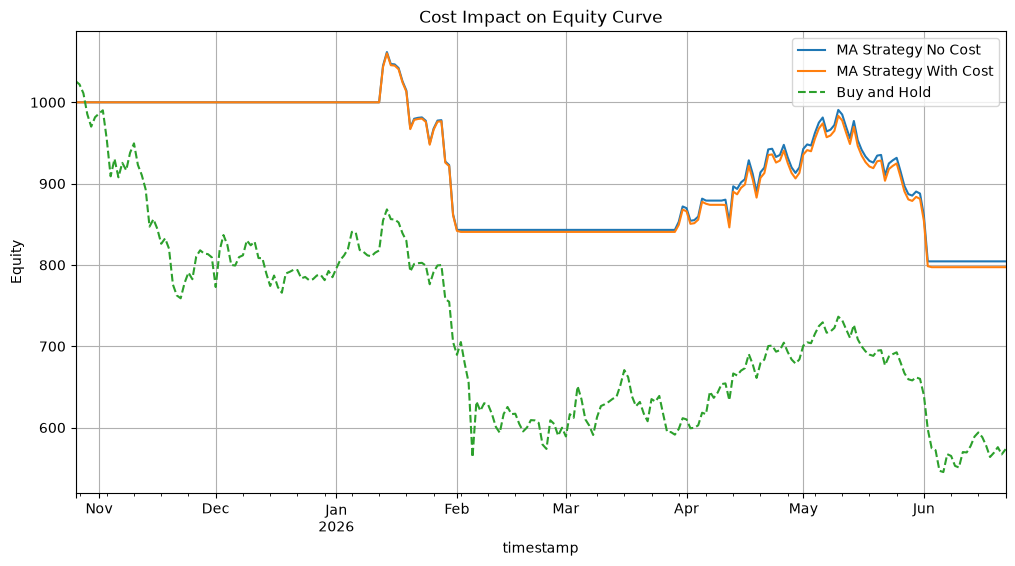

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(12, 6),
)

backtest["strategy_equity_no_cost"].plot(
    ax=ax,
    label="MA Strategy No Cost",
)

backtest["strategy_equity_with_cost"].plot(
    ax=ax,
    label="MA Strategy With Cost",
)

backtest["benchmark_equity"].plot(
    ax=ax,
    label="Buy and Hold",
    linestyle="--",
)

ax.set_title("Cost Impact on Equity Curve")
ax.set_ylabel("Equity")
ax.grid(True)
ax.legend()

plt.show()

In [33]:
trade_count = backtest["trade"].sum()

total_cost_rate_simple = trade_count * single_trade_cost_rate

print(f"交易次数：{trade_count:.0f}")
print(f"单次交易成本率：{single_trade_cost_rate:.2%}")
print(f"简单累计成本率估算：{total_cost_rate_simple:.2%}")

交易次数：6
单次交易成本率：0.15%
简单累计成本率估算：0.90%


In [34]:
for cost_rate in [0.0005, 0.001, 0.002, 0.005]:
    equity = initial_cash * (
        1 + backtest["strategy_return"]
        - backtest["trade"] * cost_rate
    ).cumprod()

    total_return = equity.iloc[-1] / initial_cash - 1
    print(f"单次成本 {cost_rate:.2%}，策略收益 {total_return:.2%}")

单次成本 0.05%，策略收益 -19.80%
单次成本 0.10%，策略收益 -20.04%
单次成本 0.20%，策略收益 -20.51%
单次成本 0.50%，策略收益 -21.92%
